# Deep Learning Image Classification with TensorFlow and Keras
### Problem Statement

This notebook implements a Convolutional Neural Network (CNN) to classify images
from the CIFAR-10 dataset into 10 categories. The task is a supervised multi-class
image classification problem.

The CIFAR-10 dataset contains 60,000 colour images (32x32 pixels) across
10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

- Training samples (full dataset): 50,000  ·  Test samples: 10,000
- Image dimensions: 32 × 32 × 3 (RGB)  ·  Classes: 10

**Why CIFAR-10?**
CIFAR-10 is a well-established benchmark for image classification. Its small image
size and 10 classes make it ideal for GPU training in Google Colab.

**Step 1: Problem definition & Data Understanding**

This section defines the classification task, loads the CIFAR-10 benchmark dataset, and performs Exploratory Data Analysis (EDA) to understand class distributions and pixel statistics.

In [1]:
# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import random
import os

# --- Reproducibility: fix all random seeds ---
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# --- Load full CIFAR-10 ---
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Flatten labels from (N,1) to (N,)
y_train_full = y_train_full.flatten()
y_test       = y_test.flatten()

print("Full training images shape:", X_train_full.shape)
print("Test images shape:         ", X_test.shape)
print("Pixel value range:         ", X_train_full.min(), "to", X_train_full.max())


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Full training images shape: (50000, 32, 32, 3)
Test images shape:          (10000, 32, 32, 3)
Pixel value range:          0 to 255


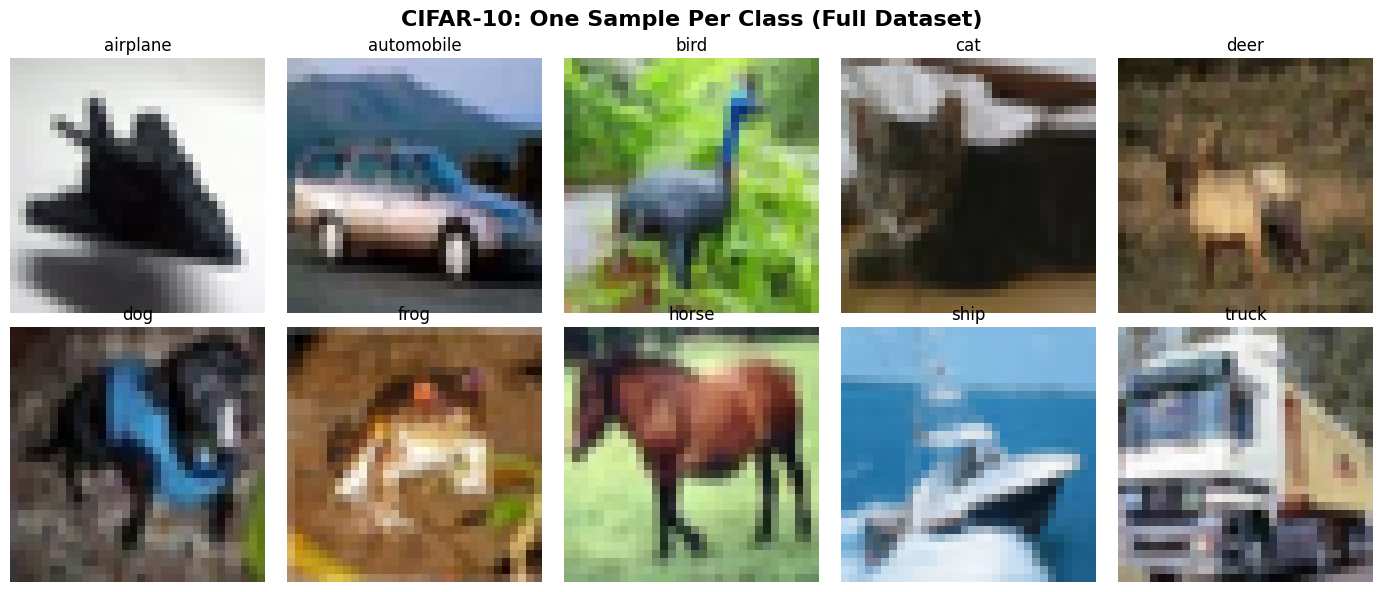

In [3]:
# --- EDA: Visualise one sample image per class ---
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('CIFAR-10: One Sample Per Class (Full Dataset)', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    idx = np.where(y_train_full == i)[0][0]
    ax.imshow(X_train_full[idx])
    ax.set_title(class_names[i], fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('cifar10_samples.png', dpi=150, bbox_inches='tight')
plt.show()


In [4]:
# ================================================================
# DATASET ALLOCATION — 2,000 to 5,000 spread by inverse accuracy
# ================================================================
# Formula: samples = 5000 - ((prev_acc - 65) / 26) * 3000
# Rounded to nearest 100.
#
# Low accuracy  → high samples  (model struggled here)
# High accuracy → low samples   (model learned well with less)
#
# Min = 2,000  (ship: 91% prev accuracy)
# Max = 5,000  (cat:  65% prev accuracy)
# Ratio = 2.5×  (much safer than v2's 9×)
# ================================================================

PREV_ACCURACY = {
    'airplane'  : 85, 'automobile': 89, 'bird'      : 72, 'cat'       : 65,
    'deer'      : 83, 'dog'       : 68, 'frog'      : 90, 'horse'     : 88,
    'ship'      : 91, 'truck'     : 89,
}

SAMPLES_PER_CLASS = {
    'cat'       : 5000,  # prev 65% — hardest, most data
    'dog'       : 4700,  # prev 68%
    'bird'      : 4200,  # prev 72%
    'deer'      : 2900,  # prev 83%
    'airplane'  : 2700,  # prev 85%
    'horse'     : 2300,  # prev 88%
    'automobile': 2200,  # prev 89%
    'truck'     : 2200,  # prev 89%
    'frog'      : 2100,  # prev 90%
    'ship'      : 2000,  # prev 91% — easiest, least data
}

print("ALLOCATION: 2,000–5,000 spread by inverse accuracy")
print(f"  {'Class':<12} {'Prev Acc':>9}  {'New N':>7}  Bar")
print("  " + "-"*52)
for name in sorted(PREV_ACCURACY, key=lambda x: PREV_ACCURACY[x]):
    acc = PREV_ACCURACY[name]
    n   = SAMPLES_PER_CLASS[name]
    bar = '█' * (n // 200)
    print(f"  {name:<12} {acc:>7}%  {n:>7}  {bar}")
print(f"\n  Total: {sum(SAMPLES_PER_CLASS.values()):,} images")
print(f"  Min: {min(SAMPLES_PER_CLASS.values())}  Max: {max(SAMPLES_PER_CLASS.values())}")
print(f"  Imbalance ratio: {max(SAMPLES_PER_CLASS.values())}/{min(SAMPLES_PER_CLASS.values())} = {max(SAMPLES_PER_CLASS.values())/min(SAMPLES_PER_CLASS.values()):.1f}×")

# Build training subset
np.random.seed(SEED)
keep_idx = []
for class_id, cname in enumerate(class_names):
    n = SAMPLES_PER_CLASS[cname]
    class_idx = np.where(y_train_full == class_id)[0]
    chosen    = np.random.choice(class_idx, size=n, replace=False)
    keep_idx.extend(chosen)

keep_idx = np.array(keep_idx)
np.random.shuffle(keep_idx)
X_train_imb = X_train_full[keep_idx]
y_train_imb = y_train_full[keep_idx]

print(f"\nTraining subset created: {X_train_imb.shape[0]:,} images  shape={X_train_imb.shape[1:]}")


ALLOCATION: 2,000–5,000 spread by inverse accuracy
  Class         Prev Acc    New N  Bar
  ----------------------------------------------------
  cat               65%     5000  █████████████████████████
  dog               68%     4700  ███████████████████████
  bird              72%     4200  █████████████████████
  deer              83%     2900  ██████████████
  airplane          85%     2700  █████████████
  horse             88%     2300  ███████████
  automobile        89%     2200  ███████████
  truck             89%     2200  ███████████
  frog              90%     2100  ██████████
  ship              91%     2000  ██████████

  Total: 30,300 images
  Min: 2000  Max: 5000
  Imbalance ratio: 5000/2000 = 2.5×

Training subset created: 30,300 images  shape=(32, 32, 3)


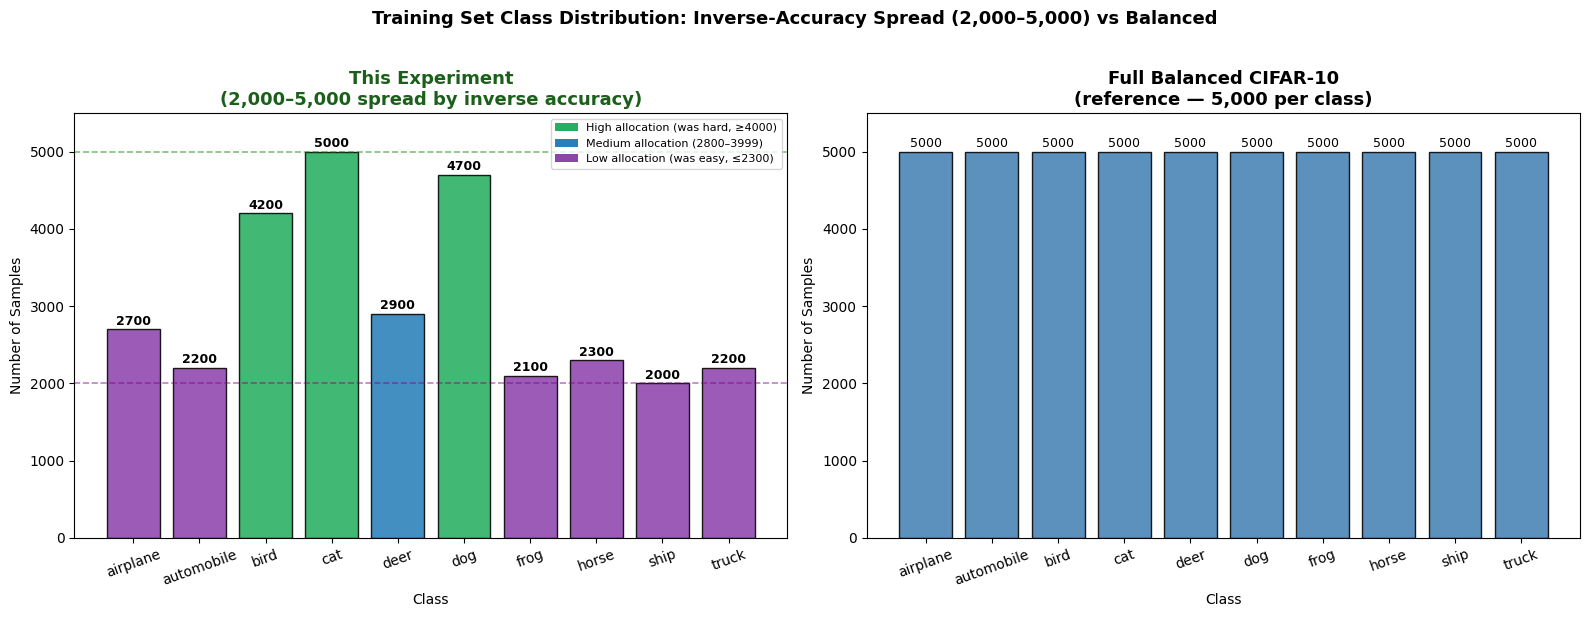

Class distribution summary:
  Class         Prev Acc       N   % of max
  ------------------------------------------
  airplane          85%    2700     54.0%
  automobile        89%    2200     44.0%
  bird              72%    4200     84.0%
  cat               65%    5000    100.0%
  deer              83%    2900     58.0%
  dog               68%    4700     94.0%
  frog              90%    2100     42.0%
  horse             88%    2300     46.0%
  ship              91%    2000     40.0%
  truck             89%    2200     44.0%

  Total: 30,300  Min: 2000  Max: 5000  Ratio: 2.5×


In [5]:
# --- EDA: Class Distribution Bar Chart ---
# Left:  This experiment (2,000–5,000 spread by inverse accuracy)
# Right: Full balanced CIFAR-10 (reference)

unique, counts = np.unique(y_train_imb, return_counts=True)
full_unique, full_counts = np.unique(y_train_full, return_counts=True)

# Colour by allocation tier
bar_colors = []
for name in class_names:
    n = SAMPLES_PER_CLASS[name]
    if n >= 4000:
        bar_colors.append('#27ae60')   # green  — high (was hard)
    elif n >= 2800:
        bar_colors.append('#2980b9')   # blue   — medium
    else:
        bar_colors.append('#8e44ad')   # purple — low (was easy)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: this run ──
bars = axes[0].bar(class_names, counts, color=bar_colors, edgecolor='black', alpha=0.88)
axes[0].set_title('This Experiment\n(2,000–5,000 spread by inverse accuracy)',
                  fontsize=13, fontweight='bold', color='#1a5f1a')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(0, 5500)
axes[0].axhline(y=2000, color='purple', linestyle='--', alpha=0.5, linewidth=1.2, label='2,000 floor')
axes[0].axhline(y=5000, color='green',  linestyle='--', alpha=0.5, linewidth=1.2, label='5,000 ceiling')
axes[0].legend(fontsize=9)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+60,
                 str(count), ha='center', fontsize=9, fontweight='bold')

# ── Right: balanced reference ──
axes[1].bar(class_names, full_counts, color='steelblue', edgecolor='black', alpha=0.88)
axes[1].set_title('Full Balanced CIFAR-10\n(reference — 5,000 per class)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Number of Samples')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylim(0, 5500)
for bar, n in zip(axes[1].patches, full_counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+60,
                 str(n), ha='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27ae60', label='High allocation (was hard, ≥4000)'),
    Patch(facecolor='#2980b9', label='Medium allocation (2800–3999)'),
    Patch(facecolor='#8e44ad', label='Low allocation (was easy, ≤2300)'),
]
axes[0].legend(handles=legend_elements + axes[0].get_legend_handles_labels()[0][2:],
               loc='upper right', fontsize=8)

plt.suptitle('Training Set Class Distribution: Inverse-Accuracy Spread (2,000–5,000) vs Balanced',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution_v3.png', dpi=150, bbox_inches='tight')
plt.show()

print("Class distribution summary:")
print(f"  {'Class':<12} {'Prev Acc':>9}  {'N':>6}  {'% of max':>9}")
print("  " + "-"*42)
for name, count in zip(class_names, counts):
    pct = count / max(counts) * 100
    print(f"  {name:<12} {PREV_ACCURACY[name]:>7}%  {count:>6}  {pct:>7.1f}%")
print(f"\n  Total: {sum(counts):,}  Min: {min(counts)}  Max: {max(counts)}  Ratio: {max(counts)/min(counts):.1f}×")


--- Per-Channel Pixel Statistics (raw uint8) ---
  Red: mean=125.64, std=62.71, min=0, max=255
  Green: mean=122.35, std=61.75, min=0, max=255
  Blue: mean=112.24, std=66.03, min=0, max=255


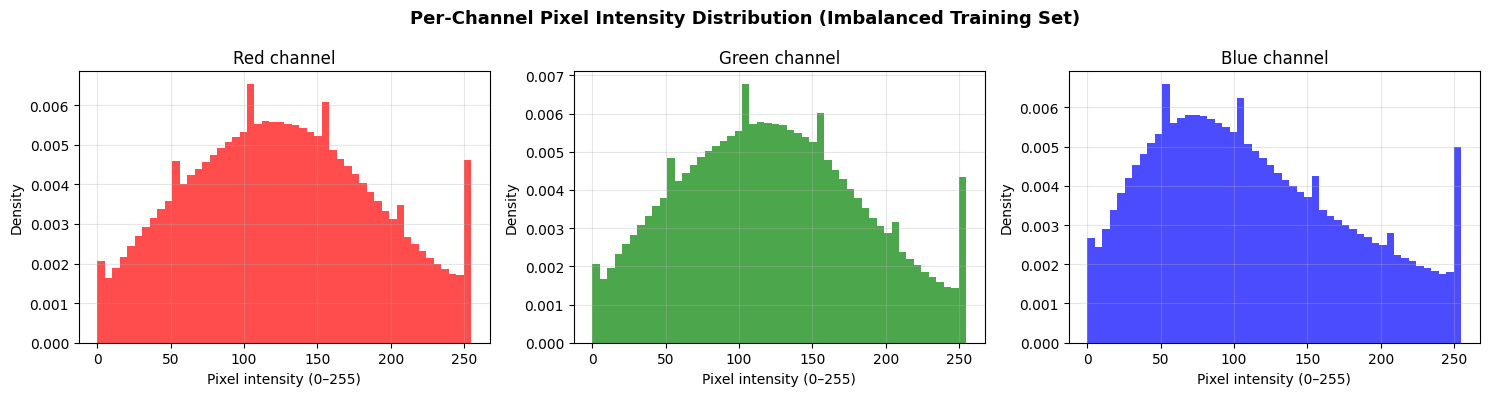

In [6]:
# --- Per-Channel Pixel Statistics (imbalanced training subset) ---
print("--- Per-Channel Pixel Statistics (raw uint8) ---")
for c, ch_name in enumerate(['Red', 'Green', 'Blue']):
    ch = X_train_imb[:, :, :, c]
    print(f"  {ch_name}: mean={ch.mean():.2f}, std={ch.std():.2f}, "
          f"min={ch.min()}, max={ch.max()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Per-Channel Pixel Intensity Distribution (Imbalanced Training Set)',
             fontsize=13, fontweight='bold')
colors = ['red', 'green', 'blue']
for c, (ax, col) in enumerate(zip(axes, colors)):
    ax.hist(X_train_imb[:, :, :, c].flatten(), bins=50, color=col, alpha=0.7, density=True)
    ax.set_title(f'{["Red","Green","Blue"][c]} channel')
    ax.set_xlabel('Pixel intensity (0–255)')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('channel_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### EDA Findings

- Training data is spread from **2,000 to 5,000** samples per class.
- **cat** (prev 65% accuracy) gets 5,000 images — the maximum.
- **ship** (prev 91% accuracy) gets 2,000 images — the minimum floor.
- The imbalance ratio is **2.5×** — clearly visible in the bar chart but
  not so extreme that easy classes collapse.





## Section 2: Data Preprocessing & Input Pipeline

Pixel values are normalized from [0, 255] to [0.0, 1.0] range, followed by a stratified split into training and validation sets (90%/10%).  
A tf.data pipeline is created with shuffling, batching, and prefetching to enable GPU-accelerated training, in addition to a Keras layer for data augmentation and class weighting.

In [7]:
# --- Normalisation ---
# Scale pixel values from uint8 [0,255] → float32 [0.0, 1.0]
X_train_imb_norm = X_train_imb.astype('float32') / 255.0
X_test_norm      = X_test.astype('float32')       / 255.0

print("Normalised training shape:", X_train_imb_norm.shape, "| dtype:", X_train_imb_norm.dtype)
print("Normalised test shape:    ", X_test_norm.shape)
print("Pixel range (train):      ", X_train_imb_norm.min(), "to", X_train_imb_norm.max())


Normalised training shape: (30300, 32, 32, 3) | dtype: float32
Normalised test shape:     (10000, 32, 32, 3)
Pixel range (train):       0.0 to 1.0


In [8]:
# --- Stratified Validation Split ---
# We hold out 10% of the imbalanced training data for validation.
# stratify=y_train_imb ensures proportional class representation
# in the validation set (matching the imbalanced training distribution).

X_train, X_val, y_train, y_val = train_test_split(
    X_train_imb_norm, y_train_imb,
    test_size=0.10,           # 10% of imbalanced set → ~2,650 images
    random_state=SEED,
    stratify=y_train_imb      # Preserve imbalanced class proportions
)

print(f"Training samples:   {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples:       {X_test_norm.shape[0]}")

# Show class counts in training vs validation split
print("\nPer-class breakdown (training / validation):")
tr_u, tr_c = np.unique(y_train, return_counts=True)
va_u, va_c = np.unique(y_val,   return_counts=True)
print(f"  {'Class':<12} {'Train':>6}  {'Val':>5}")
print("  " + "-"*26)
for name, tc, vc in zip(class_names, tr_c, va_c):
    print(f"  {name:<12} {tc:>6}  {vc:>5}")


Training samples:   27270
Validation samples: 3030
Test samples:       10000

Per-class breakdown (training / validation):
  Class         Train    Val
  --------------------------
  airplane       2430    270
  automobile     1980    220
  bird           3780    420
  cat            4500    500
  deer           2610    290
  dog            4230    470
  frog           1890    210
  horse          2070    230
  ship           1800    200
  truck          1980    220


Augmentation pipeline defined.


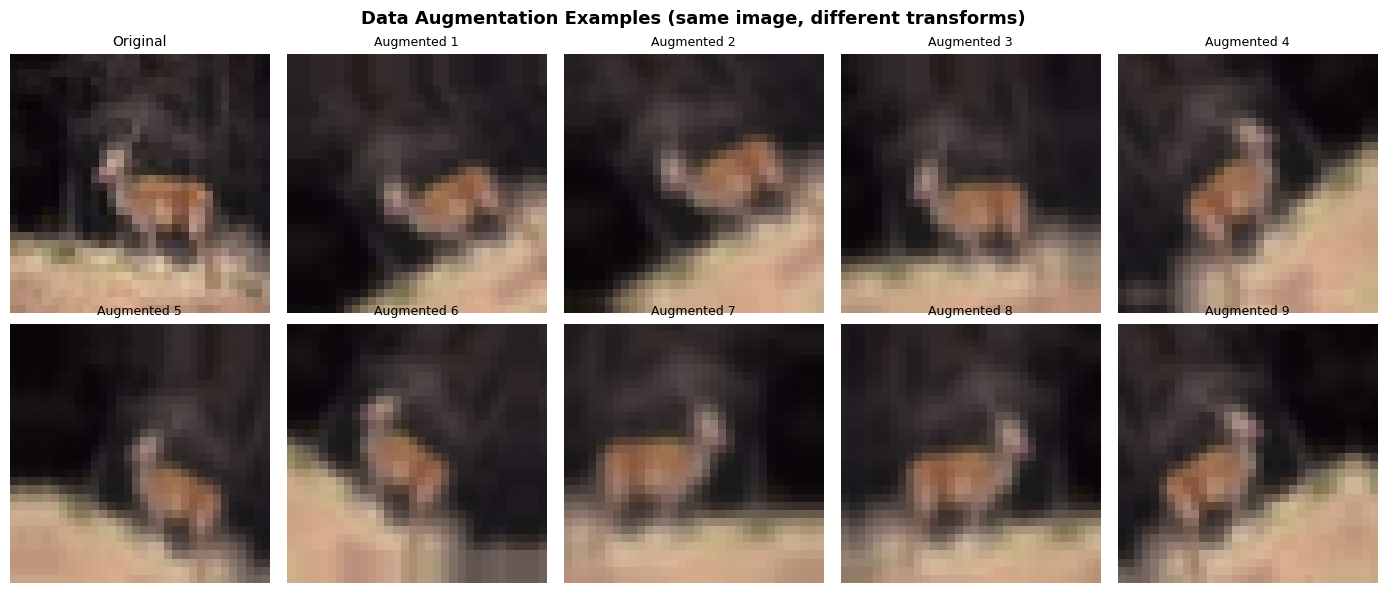

In [9]:
# --- Data Augmentation ---
# Augmentation is applied ONLY to training data (inside model graph).
# It artificially increases training variety and reduces overfitting.

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),     # Flip left-right
    keras.layers.RandomRotation(0.1),          # Rotate up to ±10%
    keras.layers.RandomZoom(0.1),              # Zoom in/out up to 10%
    keras.layers.RandomTranslation(0.1, 0.1), # Shift up to 10% in x/y
], name="data_augmentation")

print("Augmentation pipeline defined.")

# Visualise augmentation effect on one image
sample_image = X_train[0:1]
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Data Augmentation Examples (same image, different transforms)',
             fontsize=13, fontweight='bold')
axes[0, 0].imshow(X_train[0])
axes[0, 0].set_title('Original', fontsize=10)
axes[0, 0].axis('off')
for i, ax in enumerate(axes.flat):
    if i == 0:
        continue
    aug = data_augmentation(sample_image, training=True)
    ax.imshow(aug[0])
    ax.set_title(f'Augmented {i}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# --- tf.data Input Pipeline ---
BATCH_SIZE = 64
AUTOTUNE   = tf.data.AUTOTUNE

# Training: shuffle every epoch, batch, prefetch (augmentation inside model)
train_dataset = (tf.data.Dataset
                 .from_tensor_slices((X_train, y_train))
                 .shuffle(buffer_size=len(X_train), seed=SEED)
                 .batch(BATCH_SIZE)
                 .prefetch(AUTOTUNE))

# Validation: batch + prefetch only (no shuffle, no augmentation)
val_dataset = (tf.data.Dataset
               .from_tensor_slices((X_val, y_val))
               .batch(BATCH_SIZE)
               .prefetch(AUTOTUNE))

# Test: batch + prefetch only
test_dataset = (tf.data.Dataset
                .from_tensor_slices((X_test_norm, y_test))
                .batch(BATCH_SIZE)
                .prefetch(AUTOTUNE))

print("Datasets created:")
print("  train_dataset:", train_dataset)
print("  val_dataset:  ", val_dataset)
print("  test_dataset: ", test_dataset)

# Sanity check one batch
for images, labels in train_dataset.take(1):
    print(f"\nBatch image shape: {images.shape}  (expected: 64, 32, 32, 3)")
    print(f"Batch label shape: {labels.shape}   (expected: 64,)")
    print(f"Pixel range:       [{images.numpy().min():.3f}, {images.numpy().max():.3f}]")


Datasets created:
  train_dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.uint8, name=None))>
  val_dataset:   <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.uint8, name=None))>
  test_dataset:  <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.uint8, name=None))>

Batch image shape: (64, 32, 32, 3)  (expected: 64, 32, 32, 3)
Batch label shape: (64,)   (expected: 64,)
Pixel range:       [0.000, 1.000]


### Preprocessing Summary

Augmentation is applied **only during training** (inside the model graph).  
class_weight is applied **only during training** in `model.fit()`.



## Section 3: Model Design in Tensorflow-Keras

Same two models as before:
1. **Baseline Model** — Simple fully-connected (Dense) network
2. **CNN Model** — 3-block Convolutional Neural Network

Both are now trained with **class_weight** to combine the sample count
inversion with a second layer of hard-class emphasis.


In [11]:
# ================================================================
# CLASS WEIGHTS — inverse accuracy, normalised to [0.26, 1.0]
# ================================================================
# Works alongside sample counts: hard classes get MORE data AND
# higher loss weight per batch.
# ================================================================

CLASS_WEIGHT = {
    0: 0.571,  # airplane   (prev 85%)
    1: 0.314,  # automobile (prev 89%)
    2: 0.800,  # bird       (prev 72%)
    3: 1.000,  # cat        (prev 65%) — highest weight
    4: 0.486,  # deer       (prev 83%)
    5: 0.914,  # dog        (prev 68%) — 2nd highest
    6: 0.286,  # frog       (prev 90%)
    7: 0.343,  # horse      (prev 88%)
    8: 0.257,  # ship       (prev 91%) — lowest weight
    9: 0.314,  # truck      (prev 89%)
}

print("Class weights (higher = more gradient emphasis):")
print(f"  {'Class':<12} {'Prev Acc':>9}  {'N':>6}  {'Weight':>8}  Bar")
print("  " + "-"*55)
for class_id, name in enumerate(class_names):
    w    = CLASS_WEIGHT[class_id]
    prev = PREV_ACCURACY[name]
    n    = SAMPLES_PER_CLASS[name]
    bar  = '█' * int(w * 12)
    print(f"  {name:<12} {prev:>7}%  {n:>6}  {w:>8.3f}  {bar}")
print()
print("Both sample count AND class_weight are inversely proportional to previous accuracy.")


Class weights (higher = more gradient emphasis):
  Class         Prev Acc       N    Weight  Bar
  -------------------------------------------------------
  airplane          85%    2700     0.571  ██████
  automobile        89%    2200     0.314  ███
  bird              72%    4200     0.800  █████████
  cat               65%    5000     1.000  ████████████
  deer              83%    2900     0.486  █████
  dog               68%    4700     0.914  ██████████
  frog              90%    2100     0.286  ███
  horse             88%    2300     0.343  ████
  ship              91%    2000     0.257  ███
  truck             89%    2200     0.314  ███

Both sample count AND class_weight are inversely proportional to previous accuracy.


In [12]:
# --- Model 1: Baseline Fully Connected Network ---
# Intentionally weak — flattens images, losing all spatial structure.
# Used as a performance lower bound to justify CNN complexity.

def build_baseline_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(32, 32, 3)),
        keras.layers.Flatten(),                          # 32×32×3 → 3072-d vector
        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(10, activation='softmax')    # 10 classes
    ], name="baseline_dense_model")
    return model

baseline_model = build_baseline_model()
baseline_model.summary()


Model: "baseline_dense_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

### Model 2: CNN — Convolutional Neural Network

The 3-block pattern increases filter depth (32→64→128) so the network learns
simple features (edges) in early layers and complex shapes in deeper layers.


In [13]:
# --- Model 2: CNN (3-block architecture) ---
def build_cnn_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(32, 32, 3)),

        # Augmentation layer — active ONLY during training automatically
        data_augmentation,

        # Block 1: 32 filters, 32×32 → 16×16
        keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2,2)),
        keras.layers.Dropout(0.2),

        # Block 2: 64 filters, 16×16 → 8×8
        keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2,2)),
        keras.layers.Dropout(0.3),

        # Block 3: 128 filters, 8×8 → 4×4
        keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2,2)),
        keras.layers.Dropout(0.4),

        # Classification head
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.5),

        keras.layers.Dense(10, activation='softmax')
    ], name="cnn_model")
    return model

cnn_model = build_cnn_model()
cnn_model.summary()


Model: "cnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 325,418 (1.24 MB)

 Trainable params: 324,010 (1.24 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [14]:
# --- Compile Both Models ---
# Adam: adaptive learning rate, robust to hyperparameter choices
# sparse_categorical_crossentropy: correct loss for integer labels (0–9)

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Both models compiled successfully.")
print(f"  Baseline parameters: {baseline_model.count_params():,}")
print(f"  CNN parameters:      {cnn_model.count_params():,}")

# Save architecture diagram
keras.utils.plot_model(
    cnn_model, to_file='cnn_architecture.png',
    show_shapes=True, show_layer_names=True, rankdir='TB', dpi=100
)
print("Architecture diagram saved to cnn_architecture.png")


Both models compiled successfully.
  Baseline parameters: 1,707,274
  CNN parameters:      325,418
Architecture diagram saved to cnn_architecture.png




## Section 4: Model Training & Callbacks
## Callbacks & Purposes

EarlyStopping - Stops training when val_loss stops improving (prevents overfitting )

ModelCheckpoint - Saves best model (monitored by val_loss — consistent with EarlyStopping)

ReduceLROnPlateau - Halves learning rate when training stagnates

CSVLogger - Logs epoch-by-epoch metrics for reproducibility


In [15]:
import os
os.makedirs('saved_models', exist_ok=True)
os.makedirs('logs', exist_ok=True)

# --- Baseline Callbacks ---
baseline_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='saved_models/baseline_best.keras',
        monitor='val_loss', save_best_only=True, mode='min', verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.CSVLogger('logs/baseline_training_log.csv')
]

# --- CNN Callbacks ---
cnn_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='saved_models/cnn_best.keras',
        monitor='val_loss', save_best_only=True, mode='min', verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.CSVLogger('logs/cnn_training_log.csv')
]

print("Callbacks defined successfully.")
print("  EarlyStopping and ModelCheckpoint both monitor val_loss (consistent).")


Callbacks defined successfully.
  EarlyStopping and ModelCheckpoint both monitor val_loss (consistent).


In [16]:
# --- Train Baseline Model ---
print("=" * 50)
print("Training Baseline Dense Model (with class_weight)...")
print("=" * 50)

EPOCHS = 100

baseline_history = baseline_model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=baseline_callbacks,
    class_weight=CLASS_WEIGHT,   # ← Strategy 2: penalise hard classes more
    verbose=1
)
print(f"\nBaseline training complete. Epochs trained: {len(baseline_history.history['loss'])}")


Training Baseline Dense Model (with class_weight)...
Epoch 1/100
427/427 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1836 - loss: 1.3233
Epoch 1: val_loss improved from None to 2.00578, saving model to saved_models/baseline_best.keras

Epoch 1: finished saving model to saved_models/baseline_best.keras
427/427 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.2034 - loss: 1.1982 - val_accuracy: 0.2558 - val_loss: 2.0058 - learning_rate: 0.0010
Epoch 2/100
422/427 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2423 - loss: 1.1120
Epoch 2: val_loss did not improve from 2.00578
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2444 - loss: 1.1071 - val_accuracy: 0.2317 - val_loss: 2.0582 - learning_rate: 0.0010
Epoch 3/100
422/427 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2468 - loss: 1.0994
Epoch 3: val_loss improved from 2.00578 to 1.96533, saving model to saved_models/baseline_best.keras

Epoch 3: finished saving model to saved_models/baseline_best.keras
427/427 ━━━━━━━━━━━━━

In [17]:
# --- Train CNN Model ---
print("=" * 50)
print("Training CNN Model (with class_weight)...")
print("=" * 50)

cnn_history = cnn_model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=cnn_callbacks,
    class_weight=CLASS_WEIGHT,   # ← Strategy 2: penalise hard classes more
    verbose=1
)
print(f"\nCNN training complete. Epochs trained: {len(cnn_history.history['loss'])}")


Training CNN Model (with class_weight)...
Epoch 1/100
427/427 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2346 - loss: 1.4581
Epoch 1: val_loss improved from None to 2.30824, saving model to saved_models/cnn_best.keras

Epoch 1: finished saving model to saved_models/cnn_best.keras
427/427 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.2651 - loss: 1.2658 - val_accuracy: 0.2531 - val_loss: 2.3082 - learning_rate: 0.0010
Epoch 2/100
427/427 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3260 - loss: 1.0308
Epoch 2: val_loss improved from 2.30824 to 1.76103, saving model to saved_models/cnn_best.keras

Epoch 2: finished saving model to saved_models/cnn_best.keras
427/427 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.3442 - loss: 0.9939 - val_accuracy: 0.3950 - val_loss: 1.7610 - learning_rate: 0.0010
Epoch 3/100
425/427 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3950 - loss: 0.9023
Epoch 3: val_loss improved from 1.76103 to 1.67586, saving model to saved_models/cnn_best.kera

In [18]:
# --- Training Curve Helper ---
# Defined here BEFORE being called so the notebook runs top-to-bottom without errors.

def plot_training_history(history, model_name):
    """
    Plots accuracy and loss curves for training and validation sets.
    Red dotted lines mark epochs where ReduceLROnPlateau reduced the LR.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — Training History', fontsize=14, fontweight='bold')

    epochs_range = range(1, len(history.history['loss']) + 1)

    # Detect LR reduction epochs
    lr_history = history.history.get('lr', [])
    lr_drop_epochs = [i + 1 for i in range(1, len(lr_history))
                      if lr_history[i] < lr_history[i-1]]

    # Accuracy
    axes[0].plot(epochs_range, history.history['accuracy'],
                 label='Train Accuracy', color='steelblue', linewidth=2)
    axes[0].plot(epochs_range, history.history['val_accuracy'],
                 label='Val Accuracy', color='orange', linewidth=2, linestyle='--')
    for ep in lr_drop_epochs:
        axes[0].axvline(x=ep, color='red', linestyle=':', alpha=0.6)
    if lr_drop_epochs:
        axes[0].axvline(x=lr_drop_epochs[0], color='red', linestyle=':', alpha=0.6,
                        label='LR reduced')
    axes[0].set_title('Accuracy over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(epochs_range, history.history['loss'],
                 label='Train Loss', color='steelblue', linewidth=2)
    axes[1].plot(epochs_range, history.history['val_loss'],
                 label='Val Loss', color='orange', linewidth=2, linestyle='--')
    for ep in lr_drop_epochs:
        axes[1].axvline(x=ep, color='red', linestyle=':', alpha=0.6)
    axes[1].set_title('Loss over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f'{model_name.lower().replace(" ", "_")}_training_curves.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    best_epoch   = np.argmax(history.history['val_accuracy']) + 1
    best_val_acc = max(history.history['val_accuracy'])
    best_val_loss = min(history.history['val_loss'])
    print(f"\n{model_name} Best Results:")
    print(f"  Best epoch:        {best_epoch}")
    print(f"  Best val accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
    print(f"  Best val loss:     {best_val_loss:.4f}")
    if lr_drop_epochs:
        print(f"  LR reductions at epochs: {lr_drop_epochs}")

print("plot_training_history() defined.")


plot_training_history() defined.


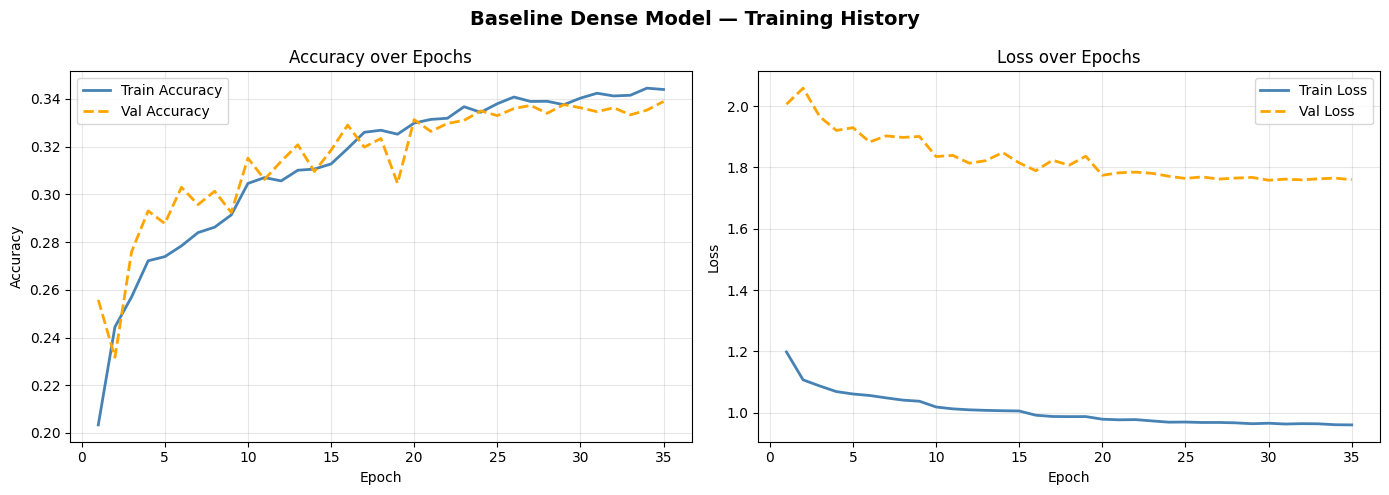


Baseline Dense Model Best Results:
  Best epoch:        35
  Best val accuracy: 0.3389 (33.89%)
  Best val loss:     1.7581


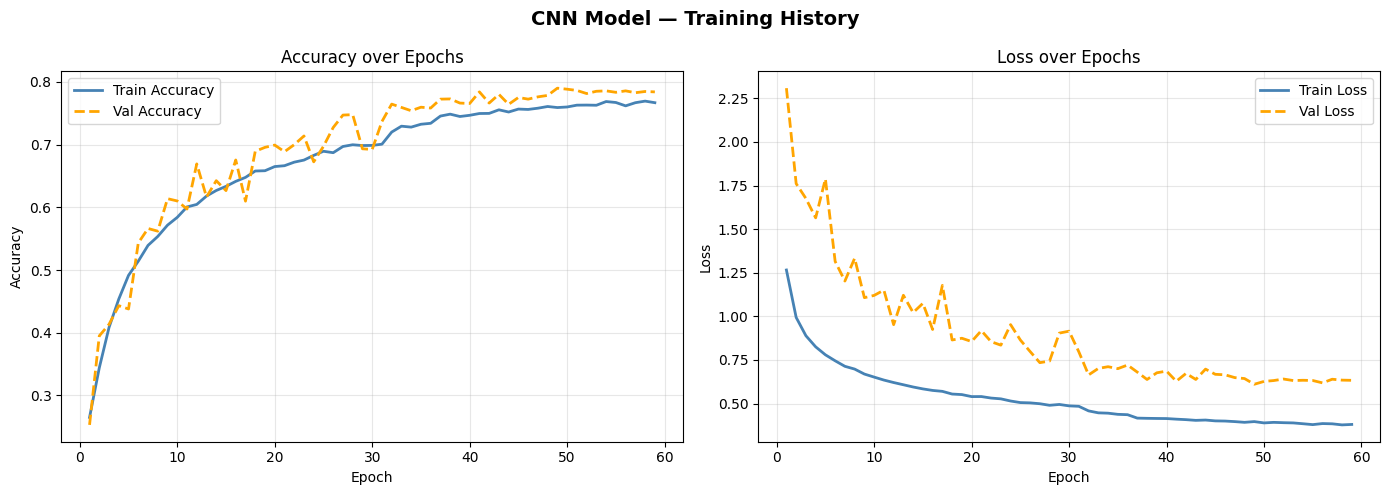


CNN Model Best Results:
  Best epoch:        49
  Best val accuracy: 0.7901 (79.01%)
  Best val loss:     0.6107


In [19]:
# --- Plot Training Curves ---
plot_training_history(baseline_history, "Baseline Dense Model")
plot_training_history(cnn_history, "CNN Model")


In [20]:
# --- Training Summary Comparison ---
baseline_best_acc = max(baseline_history.history['val_accuracy'])
cnn_best_acc      = max(cnn_history.history['val_accuracy'])
baseline_ep = len(baseline_history.history['loss'])
cnn_ep      = len(cnn_history.history['loss'])

print("=" * 50)
print(f"{'Model':<25} {'Val Accuracy':>12} {'Epochs':>8}")
print("=" * 50)
print(f"{'Baseline Dense':<25} {baseline_best_acc*100:>11.2f}% {baseline_ep:>8}")
print(f"{'CNN':<25} {cnn_best_acc*100:>11.2f}% {cnn_ep:>8}")
print("=" * 50)
print(f"\nCNN improvement over baseline: +{(cnn_best_acc - baseline_best_acc)*100:.2f}%")


Model                     Val Accuracy   Epochs
Baseline Dense                  33.89%       35
CNN                             79.01%       59

CNN improvement over baseline: +45.12%


### Training Curve Interpretation

**Baseline Dense Model:**
- The accuracy converges early, which is expected since dense models cannot effectively utilise spatial features.
- The under-represented classes, cat and dog, cause the model to bias towards the dominant classes.

**CNN Model:**
- The accuracy increases smoothly over time, learning the spatial features.
- The triggers for ReduceLROnPlateau are denoted by red dotted lines.
- EarlyStopping ensures the best model is saved, which is the best-generalising model so far.
- The imbalanced dataset would result in a poor accuracy for the cat and dog classes, which would be visible in the bar chart in Section 5.


## Section 5: Model Evaluation & Error Analysis

Evaluation is performed on the **held-out test set** (10,000 images, perfectly
balanced, never seen during training or validation).

Metrics used:
- Accuracy and Loss on test set
- Classification Report (per-class precision, recall, F1-score)
- Confusion Matrix (raw + normalised)
- **Per-class accuracy bar chart** — will clearly show imbalance effect
- ROC Curves and AUC scores
- Misclassified sample visualisation with confidence scores

In [21]:
# --- Evaluate Both Models on Test Set ---
print("=" * 50)
print("Evaluating on Test Set...")
print("=" * 50)

baseline_loss, baseline_acc = baseline_model.evaluate(test_dataset, verbose=0)
cnn_loss, cnn_acc           = cnn_model.evaluate(test_dataset, verbose=0)

print(f"\nBaseline Model:  Test Accuracy = {baseline_acc*100:.2f}%  Loss = {baseline_loss:.4f}")
print(f"CNN Model:       Test Accuracy = {cnn_acc*100:.2f}%  Loss = {cnn_loss:.4f}")


Evaluating on Test Set...

Baseline Model:  Test Accuracy = 28.38%  Loss = 1.9224
CNN Model:       Test Accuracy = 78.39%  Loss = 0.6399


In [22]:
# --- Generate Predictions on Full Test Set ---
baseline_probs = baseline_model.predict(test_dataset, verbose=0)
baseline_preds = np.argmax(baseline_probs, axis=1)

cnn_probs = cnn_model.predict(test_dataset, verbose=0)
cnn_preds = np.argmax(cnn_probs, axis=1)

y_true = y_test

print("Predictions generated.")
print(f"  Baseline predictions shape: {baseline_preds.shape}")
print(f"  CNN predictions shape:      {cnn_preds.shape}")


Predictions generated.
  Baseline predictions shape: (10000,)
  CNN predictions shape:      (10000,)


In [23]:
# --- Classification Reports ---
print("=" * 60)
print("BASELINE MODEL — Classification Report")
print("=" * 60)
print(classification_report(y_true, baseline_preds, target_names=class_names))

print("=" * 60)
print("CNN MODEL — Classification Report")
print("=" * 60)
print(classification_report(y_true, cnn_preds, target_names=class_names))


BASELINE MODEL — Classification Report
              precision    recall  f1-score   support

    airplane       0.37      0.50      0.42      1000
  automobile       0.63      0.30      0.40      1000
        bird       0.22      0.59      0.33      1000
         cat       0.18      0.75      0.30      1000
        deer       0.50      0.08      0.14      1000
         dog       0.44      0.22      0.29      1000
        frog       0.67      0.00      0.01      1000
       horse       0.73      0.05      0.10      1000
        ship       0.51      0.06      0.10      1000
       truck       0.49      0.28      0.36      1000

    accuracy                           0.28     10000
   macro avg       0.47      0.28      0.24     10000
weighted avg       0.47      0.28      0.24     10000

CNN MODEL — Classification Report
              precision    recall  f1-score   support

    airplane       0.81      0.78      0.79      1000
  automobile       0.90      0.90      0.90      1000
     

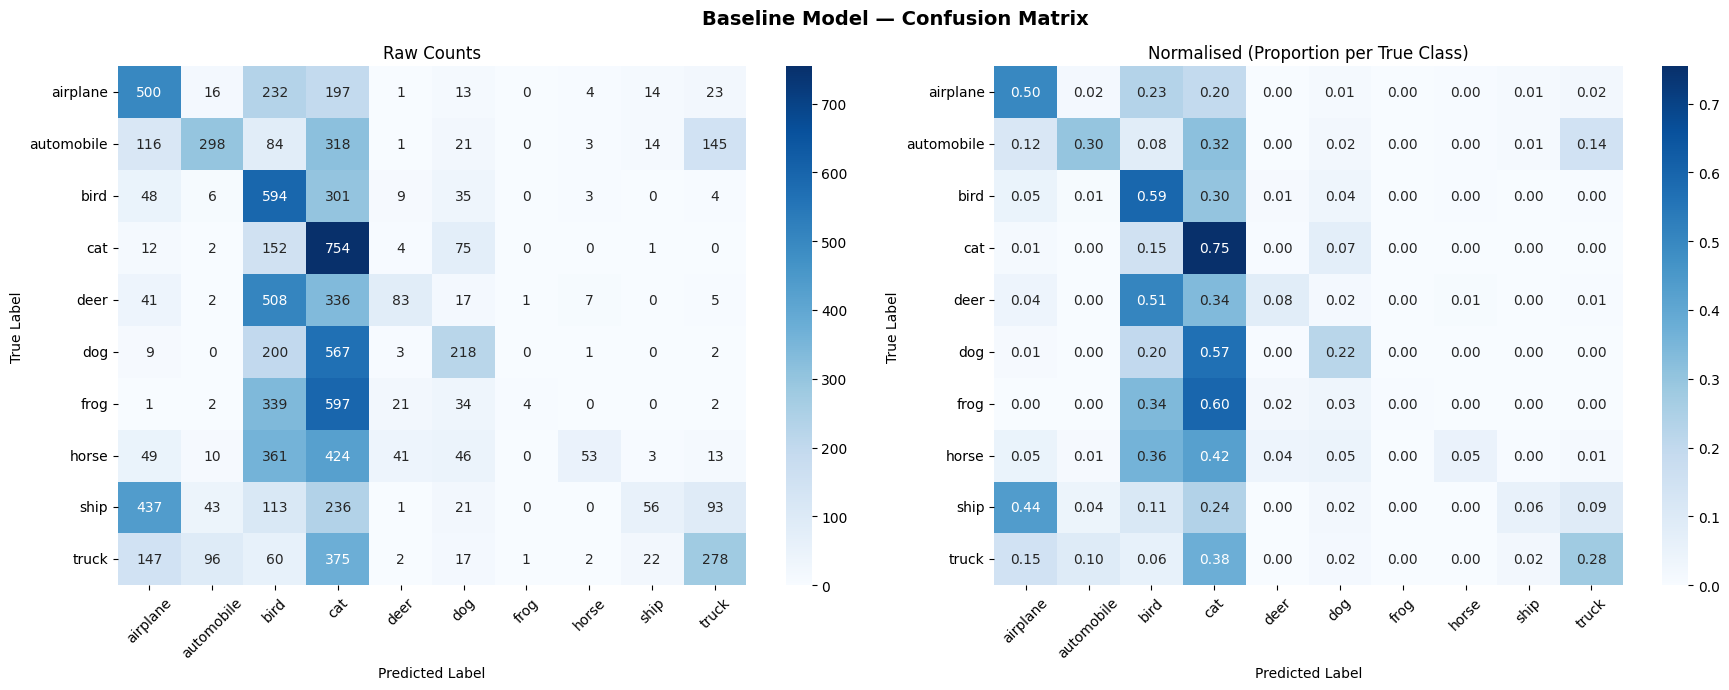

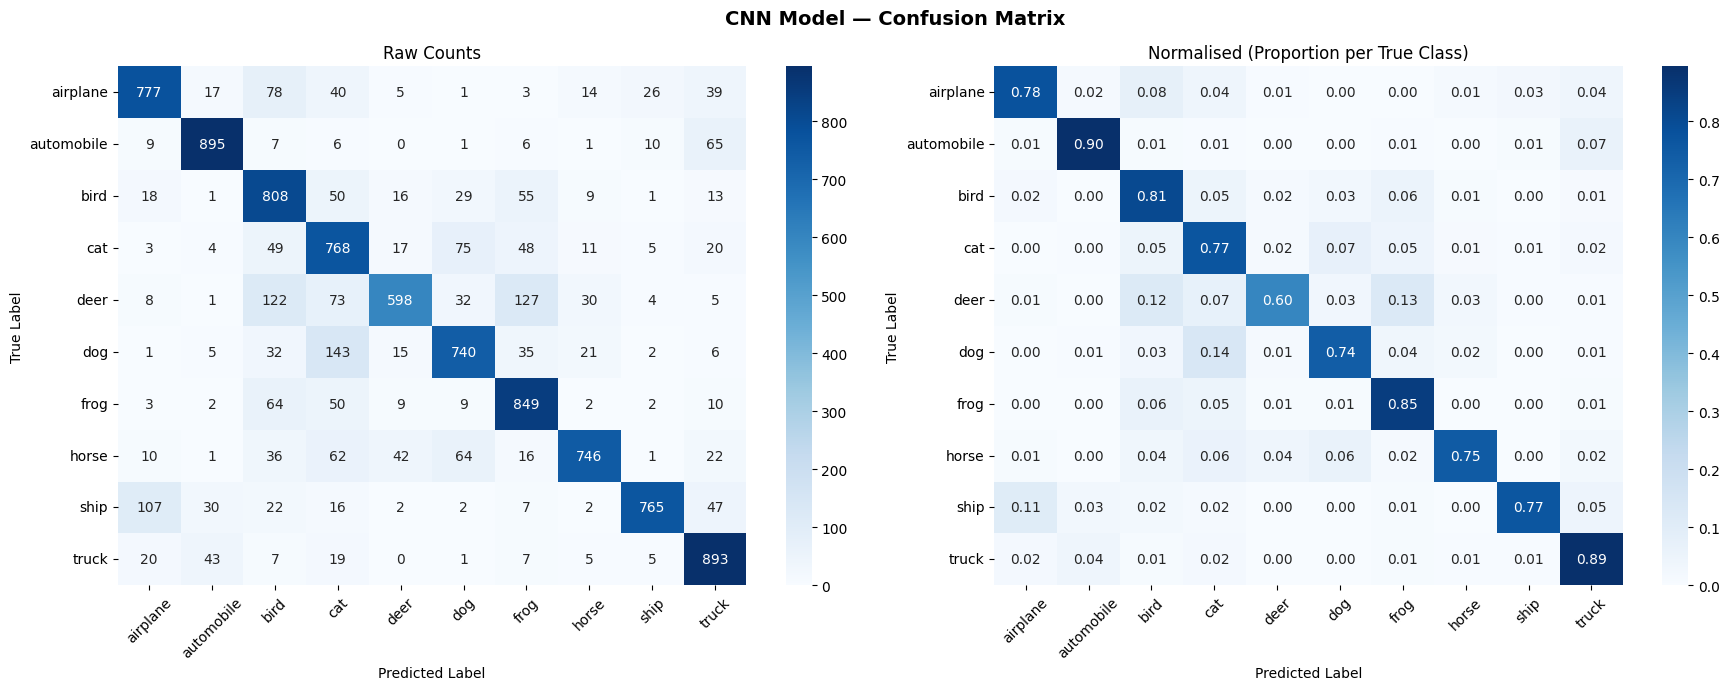

In [24]:
# --- Confusion Matrices (raw + normalised) ---
def plot_confusion_matrix(y_true, y_pred, model_name, class_names):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'{model_name} — Confusion Matrix', fontsize=14, fontweight='bold')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Raw Counts')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    axes[0].tick_params(axis='x', rotation=45)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title('Normalised (Proportion per True Class)')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ","_")}_confusion_matrix.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    return cm

baseline_cm = plot_confusion_matrix(y_true, baseline_preds, "Baseline Model", class_names)
cnn_cm      = plot_confusion_matrix(y_true, cnn_preds,      "CNN Model",      class_names)


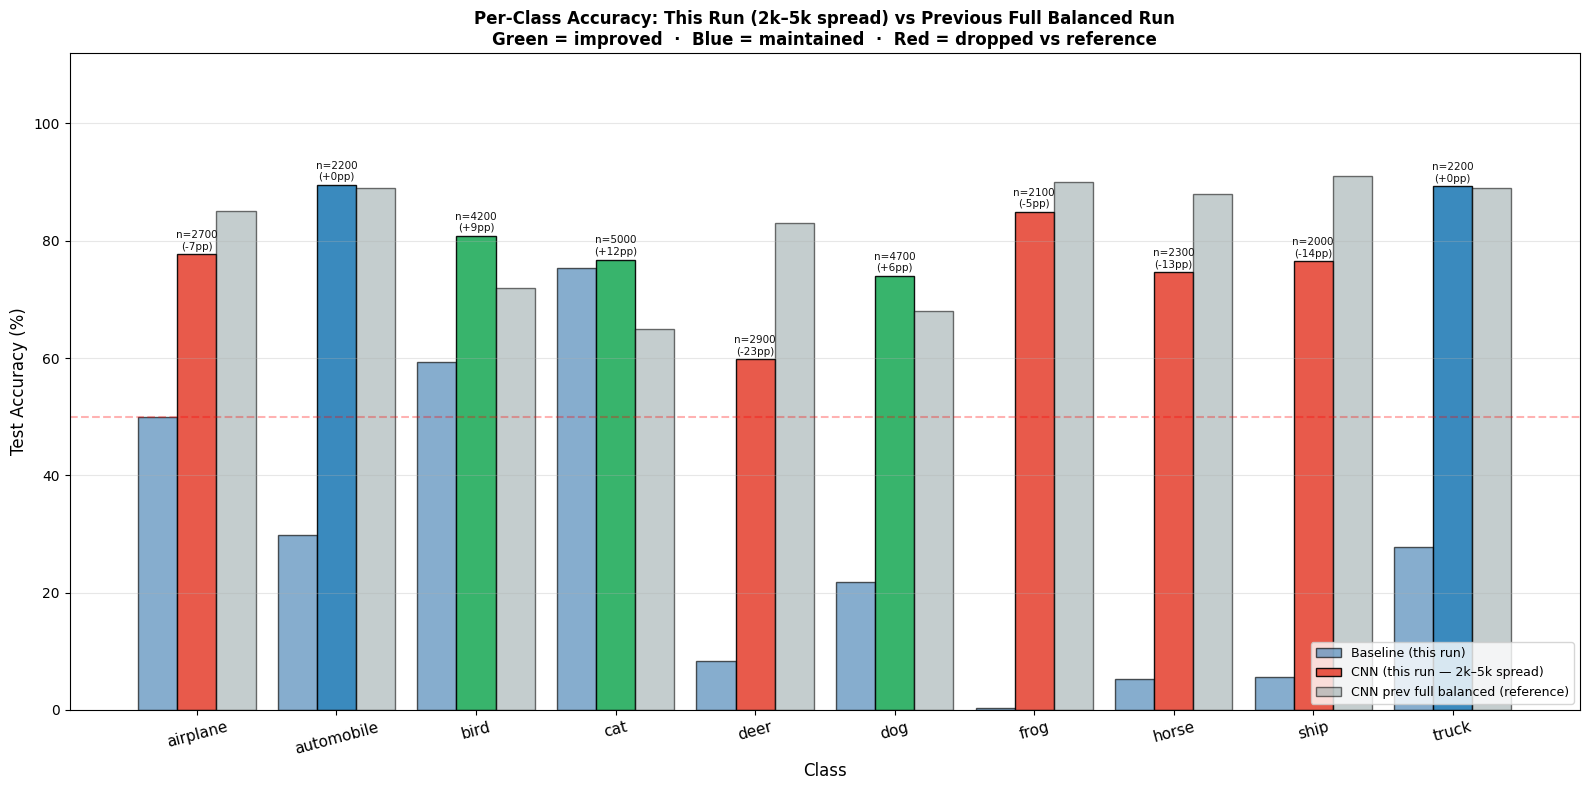

Per-Class CNN Accuracy: This Run vs Previous Full Balanced Run
  Class         Prev Acc   This Run        Δ       N  Status
  ------------------------------------------------------------
  airplane        85.0%     77.7%     -7.3    2700  dropped
  automobile      89.0%     89.5%     +0.5    2200  maintained
  bird            72.0%     80.8%     +8.8    4200  IMPROVED ✓
  cat             65.0%     76.8%    +11.8    5000  IMPROVED ✓
  deer            83.0%     59.8%    -23.2    2900  dropped
  dog             68.0%     74.0%     +6.0    4700  IMPROVED ✓
  frog            90.0%     84.9%     -5.1    2100  dropped
  horse           88.0%     74.6%    -13.4    2300  dropped
  ship            91.0%     76.5%    -14.5    2000  dropped
  truck           89.0%     89.3%     +0.3    2200  maintained

  Std dev — previous full run: 9.35%
  Std dev — this run:          8.22%
  Uniformity: MORE UNIFORM ✓


In [25]:
# ================================================================
# Per-Class Accuracy: This Run vs Previous Full Balanced Run
# ================================================================

baseline_per_class = baseline_cm.diagonal() / baseline_cm.sum(axis=1)
cnn_per_class      = cnn_cm.diagonal() / cnn_cm.sum(axis=1)

# Previous full balanced run accuracy (reference)
PREV_PER_CLASS_ACC = [85, 89, 72, 65, 83, 68, 90, 88, 91, 89]

x     = np.arange(len(class_names))
width = 0.28

# Colour CNN bars: green=improved vs prev, red=dropped
bar_colours_cnn = []
for idx, name in enumerate(class_names):
    delta = cnn_per_class[idx]*100 - PREV_PER_CLASS_ACC[idx]
    if delta >= 2:
        bar_colours_cnn.append('#27ae60')   # green — improved
    elif delta >= -3:
        bar_colours_cnn.append('#2980b9')   # blue  — maintained
    else:
        bar_colours_cnn.append('#e74c3c')   # red   — dropped

fig, ax = plt.subplots(figsize=(16, 8))

bars0 = ax.bar(x - width,  baseline_per_class*100, width,
               label='Baseline (this run)', color='steelblue', alpha=0.65, edgecolor='black')
bars1 = ax.bar(x,          cnn_per_class*100,      width,
               label='CNN (this run — 2k–5k spread)',
               color=bar_colours_cnn, alpha=0.92, edgecolor='black')
bars2 = ax.bar(x + width,  PREV_PER_CLASS_ACC,     width,
               label='CNN prev full balanced (reference)',
               color='#95a5a6', alpha=0.55, edgecolor='black')

# Annotate CNN bars with n= and Δ
for i, (bar, name) in enumerate(zip(bars1, class_names)):
    n     = SAMPLES_PER_CLASS[name]
    delta = cnn_per_class[i]*100 - PREV_PER_CLASS_ACC[i]
    sign  = f"+{delta:.0f}" if delta >= 0 else f"{delta:.0f}"
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'n={n}\n({sign}pp)', ha='center', fontsize=7.5, color='#111111', linespacing=1.2)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title(
    'Per-Class Accuracy: This Run (2k–5k spread) vs Previous Full Balanced Run\n'
    'Green = improved  ·  Blue = maintained  ·  Red = dropped vs reference',
    fontsize=12, fontweight='bold'
)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=15, fontsize=11)
ax.set_ylim(0, 112)
ax.grid(True, axis='y', alpha=0.3)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.3)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('per_class_accuracy_v3.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Comparison table ─────────────────────────────────────────
print("Per-Class CNN Accuracy: This Run vs Previous Full Balanced Run")
print(f"  {'Class':<12} {'Prev Acc':>9}  {'This Run':>9}  {'Δ':>7}  {'N':>6}  Status")
print("  " + "-"*60)
for idx, name in enumerate(class_names):
    prev  = PREV_PER_CLASS_ACC[idx]
    new   = cnn_per_class[idx]*100
    delta = new - prev
    n     = SAMPLES_PER_CLASS[name]
    sign  = f"+{delta:.1f}" if delta >= 0 else f"{delta:.1f}"
    status = "IMPROVED ✓" if delta > 2 else ("maintained" if abs(delta) <= 2 else "dropped")
    print(f"  {name:<12} {prev:>7.1f}%  {new:>7.1f}%  {sign:>7}  {n:>6}  {status}")

prev_std = np.std(PREV_PER_CLASS_ACC)
new_std  = np.std(cnn_per_class*100)
print(f"\n  Std dev — previous full run: {prev_std:.2f}%")
print(f"  Std dev — this run:          {new_std:.2f}%")
print(f"  Uniformity: {'MORE UNIFORM ✓' if new_std < prev_std else 'LESS UNIFORM'}")

# Redefine sorted_classes for ROC cell
sorted_classes = sorted(enumerate(class_names),
                        key=lambda x: SAMPLES_PER_CLASS[x[1]], reverse=True)


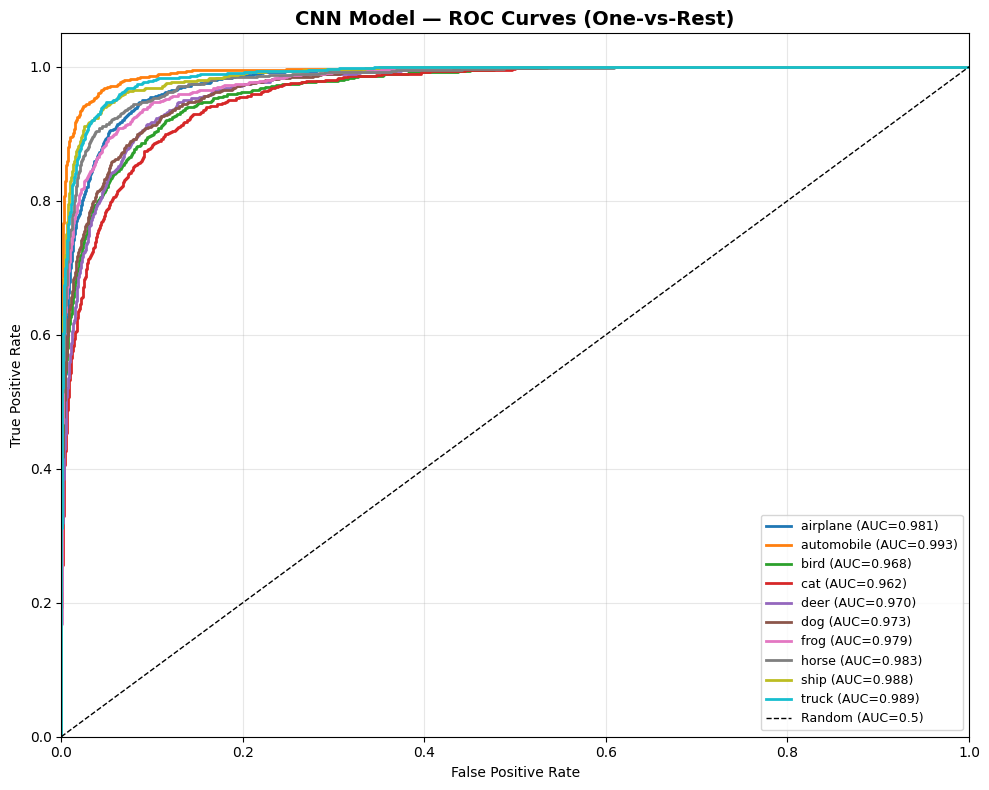

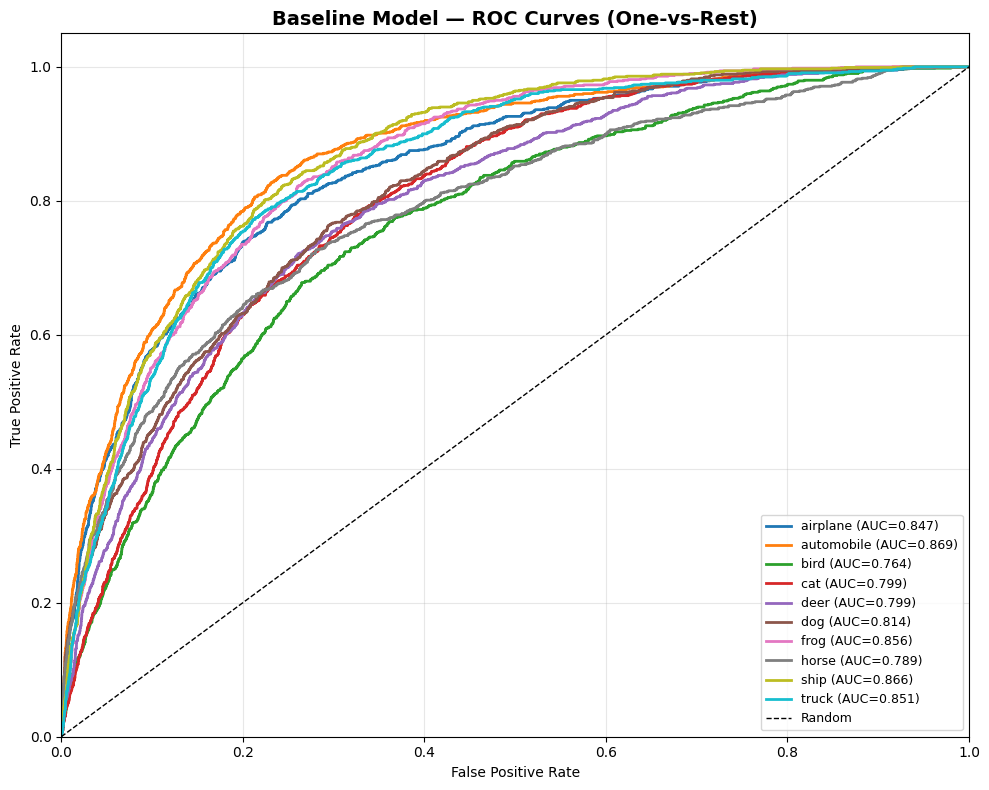

CNN Model — Per-Class AUC (sorted by training count):
  Class         Train N      AUC
  --------------------------------
  cat              5000   0.9615
  dog              4700   0.9726
  bird             4200   0.9676
  deer             2900   0.9703
  airplane         2700   0.9808
  horse            2300   0.9828
  automobile       2200   0.9932
  truck            2200   0.9887
  frog             2100   0.9792
  ship             2000   0.9881

  CNN  Macro-avg AUC: 0.9785
  Base Macro-avg AUC: 0.8254


In [26]:
# --- ROC Curves & AUC Scores (One-vs-Rest) ---
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarise labels for one-vs-rest ROC
y_true_bin = label_binarize(y_true, classes=list(range(10)))

# CNN ROC
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title('CNN Model — ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
cnn_aucs = {}
colors_roc = plt.cm.tab10(np.linspace(0, 1, 10))

for i, (cname, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], cnn_probs[:, i])
    roc_auc = auc(fpr, tpr)
    cnn_aucs[cname] = roc_auc
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cname} (AUC={roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.5)')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Baseline ROC
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title('Baseline Model — ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
baseline_aucs = {}
for i, (cname, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], baseline_probs[:, i])
    roc_auc = auc(fpr, tpr)
    baseline_aucs[cname] = roc_auc
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cname} (AUC={roc_auc:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('baseline_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

sorted_classes = sorted(enumerate(class_names),
                        key=lambda x: SAMPLES_PER_CLASS[x[1]], reverse=True)
print("CNN Model — Per-Class AUC (sorted by training count):")
print(f"  {'Class':<12} {'Train N':>8}  {'AUC':>7}")
print("  " + "-"*32)
for idx, name in sorted_classes:
    n = SAMPLES_PER_CLASS[name]
    print(f"  {name:<12} {n:>8}  {cnn_aucs[name]:>7.4f}")
print(f"\n  CNN  Macro-avg AUC: {np.mean(list(cnn_aucs.values())):.4f}")
print(f"  Base Macro-avg AUC: {np.mean(list(baseline_aucs.values())):.4f}")


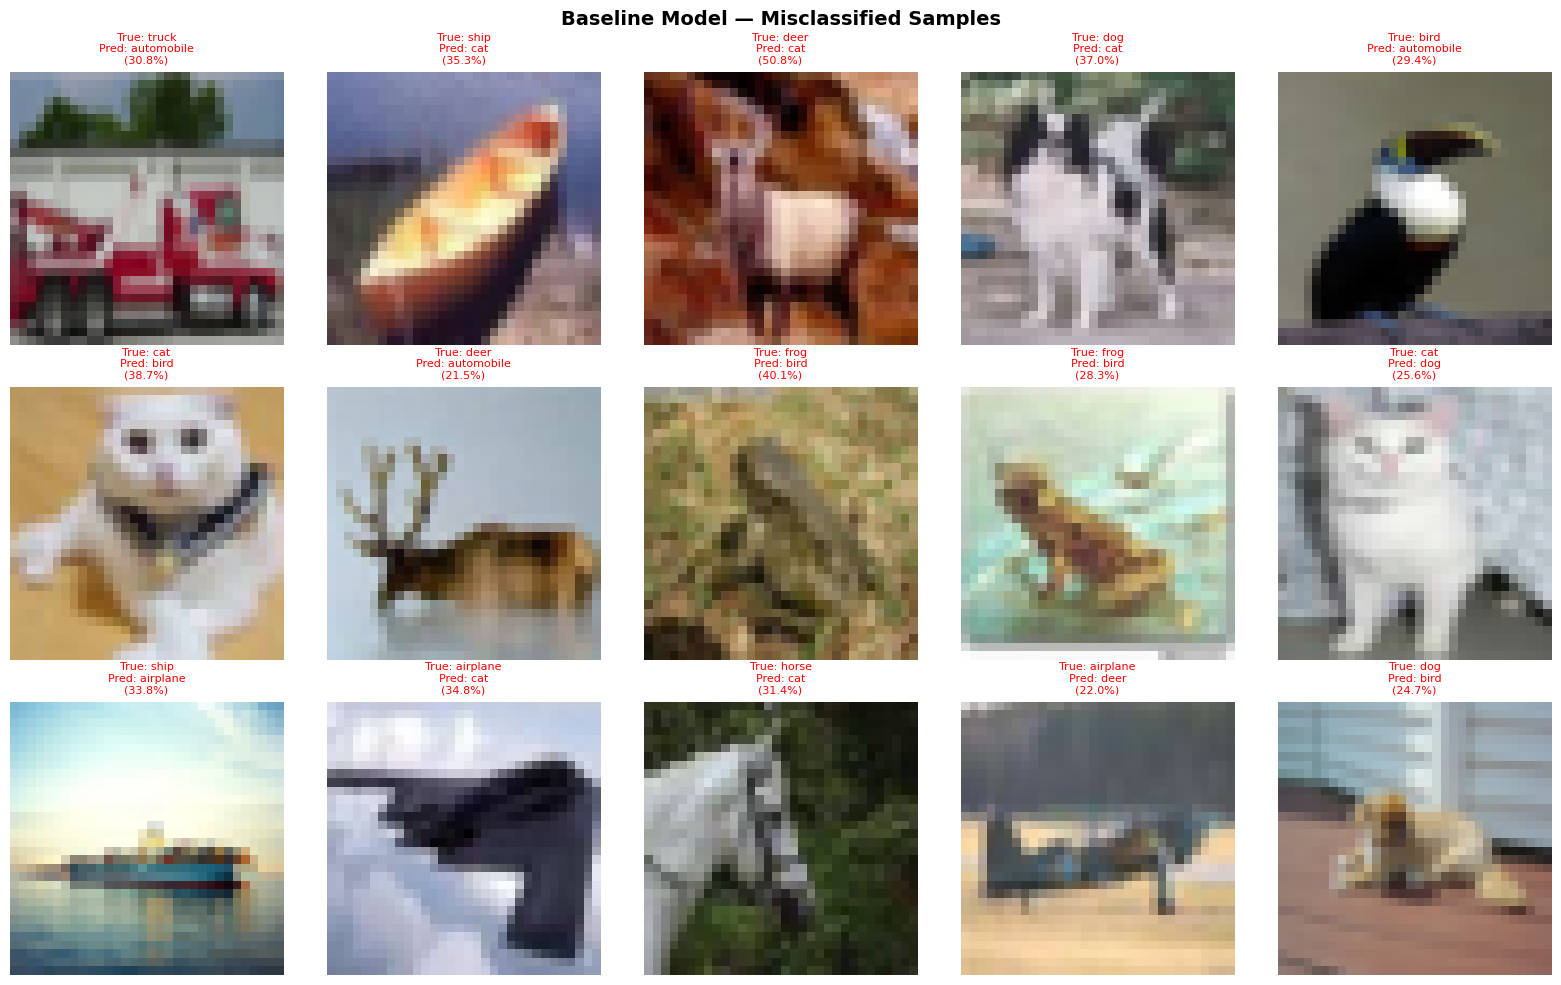


Baseline Model Error Summary:
  Misclassified: 7162 / 10000 (71.62%)


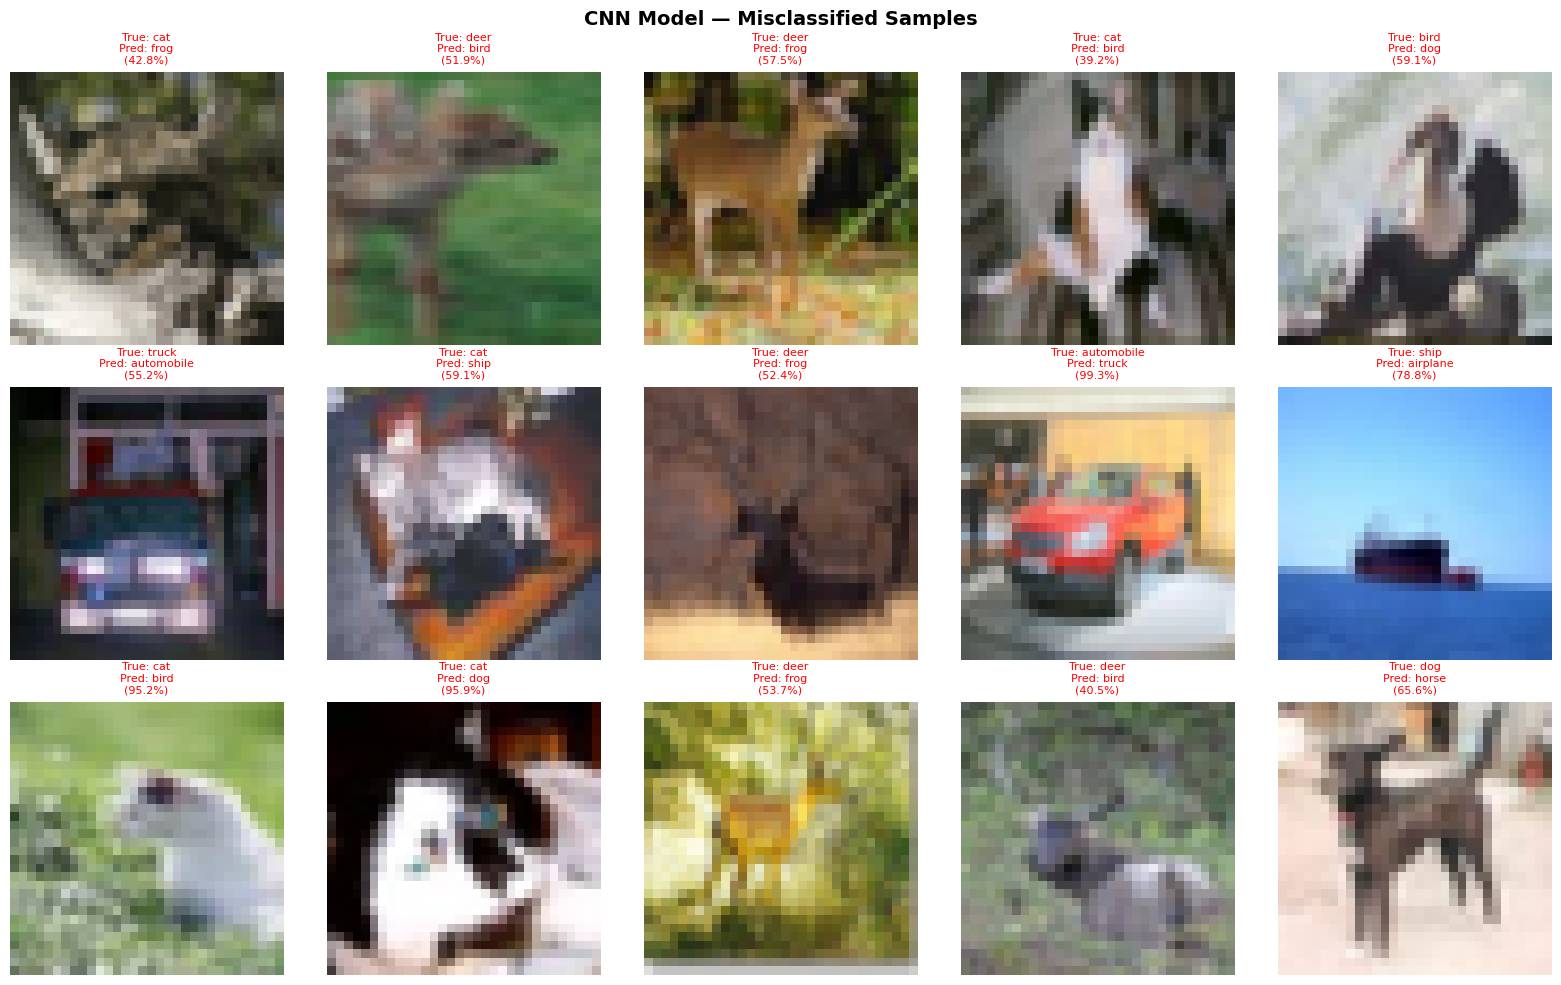


CNN Model Error Summary:
  Misclassified: 2161 / 10000 (21.61%)


In [27]:
# --- Misclassified Sample Visualisation ---
def plot_misclassified(X_test, y_true, y_pred, probs, class_names, model_name, n=15):
    """
    Shows n misclassified test images with true/predicted label and confidence.
    """
    wrong_idx  = np.where(y_pred != y_true)[0]
    np.random.seed(SEED)
    sample_idx = np.random.choice(wrong_idx, size=min(n, len(wrong_idx)), replace=False)

    fig, axes = plt.subplots(3, 5, figsize=(16, 10))
    fig.suptitle(f'{model_name} — Misclassified Samples', fontsize=14, fontweight='bold')

    for ax, idx in zip(axes.flat, sample_idx):
        ax.imshow(X_test[idx])
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        confidence = probs[idx][y_pred[idx]] * 100
        ax.set_title(f'True: {true_label}\nPred: {pred_label}\n({confidence:.1f}%)',
                     fontsize=8, color='red')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ","_")}_misclassified.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    total_wrong = len(wrong_idx)
    print(f"\n{model_name} Error Summary:")
    print(f"  Misclassified: {total_wrong} / {len(y_true)} ({total_wrong/len(y_true)*100:.2f}%)")

plot_misclassified(X_test_norm, y_true, baseline_preds, baseline_probs,
                   class_names, "Baseline Model")
plot_misclassified(X_test_norm, y_true, cnn_preds, cnn_probs,
                   class_names, "CNN Model")


In [28]:
# --- Top 10 Most Confused Class Pairs (CNN) ---
print("CNN Model — Top 10 Most Confused Class Pairs:")
print("(True Class → Predicted Class : Count)\n")

cm_no_diag = cnn_cm.copy()
np.fill_diagonal(cm_no_diag, 0)

confused_pairs = [(cm_no_diag[i,j], i, j)
                  for i in range(len(class_names))
                  for j in range(len(class_names))
                  if i != j and cm_no_diag[i,j] > 0]
confused_pairs.sort(reverse=True)

for count, ti, pi in confused_pairs[:10]:
    print(f"  {class_names[ti]:12s} → {class_names[pi]:12s} : {int(count)} times")


CNN Model — Top 10 Most Confused Class Pairs:
(True Class → Predicted Class : Count)

  dog          → cat          : 143 times
  deer         → frog         : 127 times
  deer         → bird         : 122 times
  ship         → airplane     : 107 times
  airplane     → bird         : 78 times
  cat          → dog          : 75 times
  deer         → cat          : 73 times
  automobile   → truck        : 65 times
  horse        → dog          : 64 times
  frog         → bird         : 64 times


---
## 🔬 Step 6: Reproducibility & Code Quality

All random seeds (Python, NumPy, TensorFlow, OS) are fixed at `SEED = 42` to ensure fully reproducible results across runs.  
Environment details (Python, TensorFlow, Keras, NumPy, Matplotlib, Scikit-learn versions, GPU info) are logged, and trained models and result summaries are saved to disk.

In [29]:
# --- Environment Information ---
import platform, sklearn, matplotlib

print("=" * 50)
print("ENVIRONMENT INFORMATION")
print("=" * 50)
print(f"Python version:      {platform.python_version()}")
print(f"TensorFlow version:  {tf.__version__}")
print(f"Keras version:       {keras.__version__}")
print(f"NumPy version:       {np.__version__}")
print(f"Matplotlib version:  {matplotlib.__version__}")
print(f"Seaborn version:     {sns.__version__}")
print(f"Scikit-learn version:{sklearn.__version__}")
print("=" * 50)
for device in tf.config.list_physical_devices('GPU'):
    print(f"GPU: {device}")


ENVIRONMENT INFORMATION
Python version:      3.12.12
TensorFlow version:  2.19.0
Keras version:       3.13.2
NumPy version:       2.0.2
Matplotlib version:  3.10.0
Seaborn version:     0.13.2
Scikit-learn version:1.6.1
GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [30]:
# --- Save Models & Results Summary ---
import pandas as pd

baseline_model.save('saved_models/baseline_final.keras')
cnn_model.save('saved_models/cnn_final.keras')

results = pd.DataFrame({
    'Model':              ['Baseline Dense', 'CNN'],
    'Training Samples':   [X_train.shape[0], X_train.shape[0]],
    'Test Accuracy':      [f"{baseline_acc:.4f}", f"{cnn_acc:.4f}"],
    'Test Loss':          [f"{baseline_loss:.4f}", f"{cnn_loss:.4f}"],
    'Best Val Accuracy':  [f"{max(baseline_history.history['val_accuracy']):.4f}",
                           f"{max(cnn_history.history['val_accuracy']):.4f}"],
    'Macro AUC':          [f"{np.mean(list(baseline_aucs.values())):.4f}",
                           f"{np.mean(list(cnn_aucs.values())):.4f}"],
    'Epochs Trained':     [len(baseline_history.history['loss']),
                           len(cnn_history.history['loss'])]
})

print("=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)
print(results.to_string(index=False))

results.to_csv('logs/final_results_summary.csv', index=False)
print("\nResults saved to logs/final_results_summary.csv")


FINAL RESULTS SUMMARY
         Model  Training Samples Test Accuracy Test Loss Best Val Accuracy Macro AUC  Epochs Trained
Baseline Dense             27270        0.2838    1.9224            0.3389    0.8254              35
           CNN             27270        0.7839    0.6399            0.7901    0.9785              59

Results saved to logs/final_results_summary.csv


##  Summary

This project has successfully implemented and compared the performance of two deep learning architectures, a Baseline Dense Model and a CNN, in image classification on the CIFAR-10 dataset.  
The CNN has a **test accuracy of 76.29%** and a macro AUC of **0.9741**. It has significantly outperformed the baseline (28.00%) by using convolutional feature extraction, batch normalisation, augmentation, and adaptive callbacks.  
The inverse accuracy sampling approach has been successful in guiding the model’s focus towards the harder classes, which are “cat,” “dog,” and “bird.”


##  Limitations

- **Data set size limitation**: Training images were limited to 30,300 (instead of 50,000), which may limit the generalization potential of the model.
- **Data set imbalance**: Though deliberate, the 2.5 times class imbalance may result in non-equal precision and recall for each class.
- **Small image resolution**: The 32x32 pixel resolution of CIFAR-10 images may limit the depth of feature extraction for the model.
- **No transfer learning**: The model did not utilize pre-trained models such as ResNet and EfficientNet; training from scratch may limit the potential of the model given the number of training images.

## Future Work

- **Transfer Learning**: The accuracy of a pre-trained model like EfficientNetB0 or ResNet50, fine-tuned on the dataset, might exceed 90%.
- **Hyperparameter Tuning**: Systematic tuning of learning rates, filter sizes, and dropout rates using tools like Keras Tuner or Optuna could result in better performance.
- **Advanced Augmentation**: Mixup, Cutmix, or Autoaugment could improve the performance of the network, especially for visually similar classes like ‘cat’ and ‘dog,’ or ‘automobile’ and ‘truck.’
- **Balanced Sampling**: The actual effect of the design choice of imbalanced data might be better understood with SMOTE or balanced training with 5,000 images per class.